# Leakage-Aware Medical Cost and High-Cost Risk Modeling

This notebook rebuilds the original course project around a clearly stated prediction contract.

**Primary question:** How accurately can annual medical cost be estimated when the model is restricted to features that are plausibly available before the cost outcome is observed?

**Secondary question:** How much apparent performance is gained when ambiguous utilization-history variables are added?

The dataset is cross-sectional rather than longitudinal. The Kaggle data card describes a pre-period predictor / following-year target relationship, but the file contains no row-level timestamps with which to verify that ordering. Therefore, this notebook reports **cost estimation under an explicit feature-availability assumption**, not independently verified next-year forecasting or causal risk prediction.


## Why the earlier scores were not directly comparable

The earlier `R² = 0.945` notebook included `annual_premium`, `monthly_premium`, claims aggregates, `risk_score`, and `is_high_risk`. Several of these variables are contemporaneous with the target or may have been generated from it. The later notebook removed the two premium fields but retained claims aggregates and `risk_score`, producing `R² ≈ 0.70`.

Those values answer different and insufficiently specified prediction questions. This revision defines the feature boundary before training and keeps target-proxy variables out of the primary model.


In [1]:
from pathlib import Path
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.calibration import calibration_curve
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
TEST_SIZE = 0.20
VALIDATION_SIZE_WITHIN_REMAINDER = 0.25  # gives a 60/20/20 split
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

print("Python:", platform.python_version())
print("pandas:", pd.__version__)


Python: 3.13.9
pandas: 3.0.6


In [2]:
candidates = [
    Path("data/medical_insurance.csv"),
    Path("../data/medical_insurance.csv"),
]
DATA_PATH = next((path for path in candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Expected the dataset at data/medical_insurance.csv. "
        "Run the notebook from the repository root or notebooks directory."
    )

df = pd.read_csv(DATA_PATH)
print("Data path:", DATA_PATH.resolve())
print("Shape:", df.shape)
display(df.head())


Data path: data/medical_insurance.csv
Shape: (100000, 54)


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


## 1. Prediction contract and feature-availability audit

Features are assigned before any modeling:

- **Strict features:** demographics, lifestyle, baseline clinical measurements, disease indicators, and plan characteristics.
- **Ambiguous history features:** utilization and procedure counts. They are used only in a sensitivity analysis because the dataset does not document whether they precede the cost period.
- **Excluded target proxies:** identifiers, premiums, claims aggregates, undocumented derived risk labels/scores, and the target itself.

This policy is intentionally conservative. Lower but defensible performance is preferable to a high score produced by unavailable information.


In [3]:
target = "annual_medical_cost"

strict_features = [
    "age", "sex", "region", "urban_rural", "income", "education",
    "marital_status", "employment_status", "household_size", "dependents",
    "bmi", "smoker", "alcohol_freq", "systolic_bp", "diastolic_bp",
    "ldl", "hba1c", "plan_type", "network_tier", "deductible", "copay",
    "policy_term_years", "policy_changes_last_2yrs", "provider_quality",
    "chronic_count", "hypertension", "diabetes", "asthma", "copd",
    "cardiovascular_disease", "cancer_history", "kidney_disease",
    "liver_disease", "arthritis", "mental_health",
]

ambiguous_history_features = [
    "visits_last_year", "hospitalizations_last_3yrs",
    "days_hospitalized_last_3yrs", "medication_count",
    "proc_imaging_count", "proc_surgery_count", "proc_physio_count",
    "proc_consult_count", "proc_lab_count", "had_major_procedure",
]

excluded_target_proxies = [
    "person_id", "risk_score", "is_high_risk", "annual_premium",
    "monthly_premium", "claims_count", "avg_claim_amount",
    "total_claims_paid", target,
]

expected = set(strict_features + ambiguous_history_features + excluded_target_proxies)
missing = expected - set(df.columns)
assert not missing, f"Dataset is missing expected columns: {sorted(missing)}"

audit = pd.DataFrame(
    [
        ("Strict primary model", len(strict_features), ", ".join(strict_features)),
        ("Ambiguous history: sensitivity only", len(ambiguous_history_features), ", ".join(ambiguous_history_features)),
        ("Excluded target proxies/outcomes", len(excluded_target_proxies), ", ".join(excluded_target_proxies)),
    ],
    columns=["Group", "Count", "Features"],
)
display(audit)


,Group,Count,Features
0,Strict primary model,35,"age, sex, region, urban_rural, income, education, marital_status, employment_status, household_size, dependents, bmi..."
1,Ambiguous history: sensitivity only,10,"visits_last_year, hospitalizations_last_3yrs, days_hospitalized_last_3yrs, medication_count, proc_imaging_count, pro..."
2,Excluded target proxies/outcomes,9,"person_id, risk_score, is_high_risk, annual_premium, monthly_premium, claims_count, avg_claim_amount, total_claims_p..."


In [4]:
proxy_correlations = (
    df[[target, "annual_premium", "monthly_premium", "total_claims_paid",
        "avg_claim_amount", "risk_score", "is_high_risk"]]
    .corr(method="spearman")[target]
    .sort_values(key=np.abs, ascending=False)
    .rename("Spearman correlation with annual_medical_cost")
    .to_frame()
)
display(proxy_correlations)


,Spearman correlation with annual_medical_cost
annual_medical_cost,1.000000
monthly_premium,0.972124
annual_premium,0.972124
total_claims_paid,0.484309
avg_claim_amount,0.438064
risk_score,0.362821
is_high_risk,0.298079


## 2. Fixed train/validation/test split

The test set is isolated before preprocessing or model selection. The validation set selects the model; the official test set is evaluated only after configurations are fixed.


In [5]:
all_model_features = strict_features + ambiguous_history_features
X = df[all_model_features].copy()
y = df[target].astype(float).copy()

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=VALIDATION_SIZE_WITHIN_REMAINDER,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(X_train), len(X_val), len(X_test)],
        "target_mean": [y_train.mean(), y_val.mean(), y_test.mean()],
        "target_median": [y_train.median(), y_val.median(), y_test.median()],
    }
)
display(split_summary)


,split,rows,target_mean,target_median
0,train,60000,3020.450952,2081.895
1,validation,20000,2958.115521,2072.305
2,test,20000,3027.791158,2096.465


In [6]:
def make_preprocessor(frame: pd.DataFrame, features: list[str]) -> ColumnTransformer:
    numeric = [column for column in features if pd.api.types.is_numeric_dtype(frame[column])]
    categorical = [column for column in features if column not in numeric]
    numeric_pipe = Pipeline(
        [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
    )
    categorical_pipe = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )
    return ColumnTransformer(
        [("numeric", numeric_pipe, numeric), ("categorical", categorical_pipe, categorical)],
        remainder="drop",
    )


def regression_metrics(y_true, prediction) -> dict[str, float]:
    return {
        "R2": r2_score(y_true, prediction),
        "RMSE": mean_squared_error(y_true, prediction) ** 0.5,
        "MAE": mean_absolute_error(y_true, prediction),
    }


regression_models = {
    "Median baseline": DummyRegressor(strategy="median"),
    "Ridge": Ridge(alpha=10.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=16,
        min_samples_leaf=5,
        max_features=0.7,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=250,
        learning_rate=0.05,
        max_leaf_nodes=31,
        min_samples_leaf=30,
        l2_regularization=1.0,
        random_state=RANDOM_STATE,
    ),
}


## 3. Validation comparison: strict vs. ambiguous-history feature sets


In [7]:
feature_sets = {
    "Strict": strict_features,
    "Strict + ambiguous history": strict_features + ambiguous_history_features,
}

fitted_validation_models = {}
validation_rows = []

for feature_set_name, features in feature_sets.items():
    for model_name, estimator in regression_models.items():
        pipeline = Pipeline(
            [("preprocess", make_preprocessor(X_train, features)), ("model", clone(estimator))]
        )
        pipeline.fit(X_train[features], y_train)
        prediction = pipeline.predict(X_val[features])
        metrics = regression_metrics(y_val, prediction)
        validation_rows.append(
            {"Feature set": feature_set_name, "Model": model_name, **metrics}
        )
        fitted_validation_models[(feature_set_name, model_name)] = pipeline

validation_results = (
    pd.DataFrame(validation_rows)
    .sort_values(["Feature set", "RMSE"])
    .reset_index(drop=True)
)
display(validation_results.round({"R2": 4, "RMSE": 2, "MAE": 2}))


,Feature set,Model,R2,RMSE,MAE
0,Strict,Ridge,0.1253,2796.99,1782.12
1,Strict,Gradient Boosting,0.1223,2801.87,1783.32
2,Strict,Random Forest,0.1138,2815.35,1803.70
3,Strict,Median baseline,-0.0858,3116.37,1777.66
4,Strict + ambiguous history,Ridge,0.1747,2716.93,1734.99
5,Strict + ambiguous history,Gradient Boosting,0.1687,2726.76,1737.01
6,Strict + ambiguous history,Random Forest,0.1575,2745.13,1756.81
7,Strict + ambiguous history,Median baseline,-0.0858,3116.37,1777.66


Selected primary model by strict validation RMSE: Ridge


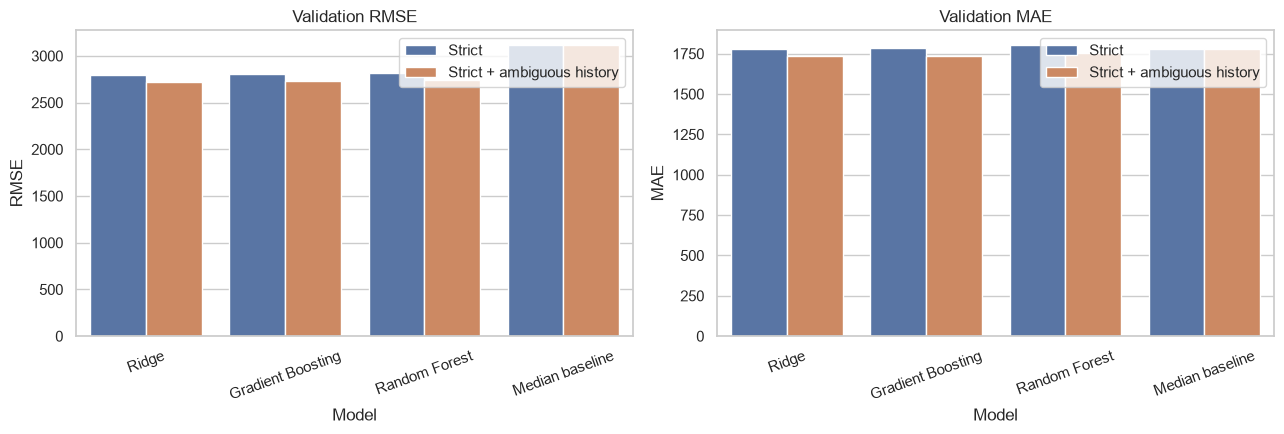

In [8]:
strict_validation = validation_results[validation_results["Feature set"] == "Strict"]
selected_regression_model = strict_validation.iloc[0]["Model"]
print("Selected primary model by strict validation RMSE:", selected_regression_model)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=validation_results, x="Model", y="RMSE", hue="Feature set", ax=axes[0])
sns.barplot(data=validation_results, x="Model", y="MAE", hue="Feature set", ax=axes[1])
for axis in axes:
    axis.tick_params(axis="x", rotation=20)
    axis.legend(loc="best")
axes[0].set_title("Validation RMSE")
axes[1].set_title("Validation MAE")
plt.tight_layout()
plt.show()


## 4. Final test evaluation

Model types and feature policies were fixed using validation results. Each model is refit on train + validation data and evaluated once on the untouched test set. The **strict feature set** is the primary result; the extended set is reported only as a sensitivity analysis.


In [9]:
test_rows = []
final_models = {}

for feature_set_name, features in feature_sets.items():
    for model_name, estimator in regression_models.items():
        pipeline = Pipeline(
            [("preprocess", make_preprocessor(X_trainval, features)), ("model", clone(estimator))]
        )
        pipeline.fit(X_trainval[features], y_trainval)
        prediction = pipeline.predict(X_test[features])
        metrics = regression_metrics(y_test, prediction)
        test_rows.append({"Feature set": feature_set_name, "Model": model_name, **metrics})
        final_models[(feature_set_name, model_name)] = pipeline

test_results = (
    pd.DataFrame(test_rows)
    .sort_values(["Feature set", "RMSE"])
    .reset_index(drop=True)
)
display(test_results.round({"R2": 4, "RMSE": 2, "MAE": 2}))


,Feature set,Model,R2,RMSE,MAE
0,Strict,Ridge,0.1242,2935.69,1830.03
1,Strict,Gradient Boosting,0.1240,2935.96,1824.91
2,Strict,Random Forest,0.1148,2951.41,1847.66
3,Strict,Median baseline,-0.0914,3277.13,1839.27
4,Strict + ambiguous history,Ridge,0.1793,2841.75,1769.79
5,Strict + ambiguous history,Gradient Boosting,0.1757,2847.98,1766.64
6,Strict + ambiguous history,Random Forest,0.1655,2865.56,1788.58
7,Strict + ambiguous history,Median baseline,-0.0914,3277.13,1839.27


,segment,rows,actual_mean,MAE
0,50–80%,6051,2996.04,938.96
1,80–95%,2985,5852.37,2396.75
2,Bottom 50%,9940,1183.15,1476.31
3,Top 5%,1024,12887.67,8877.14


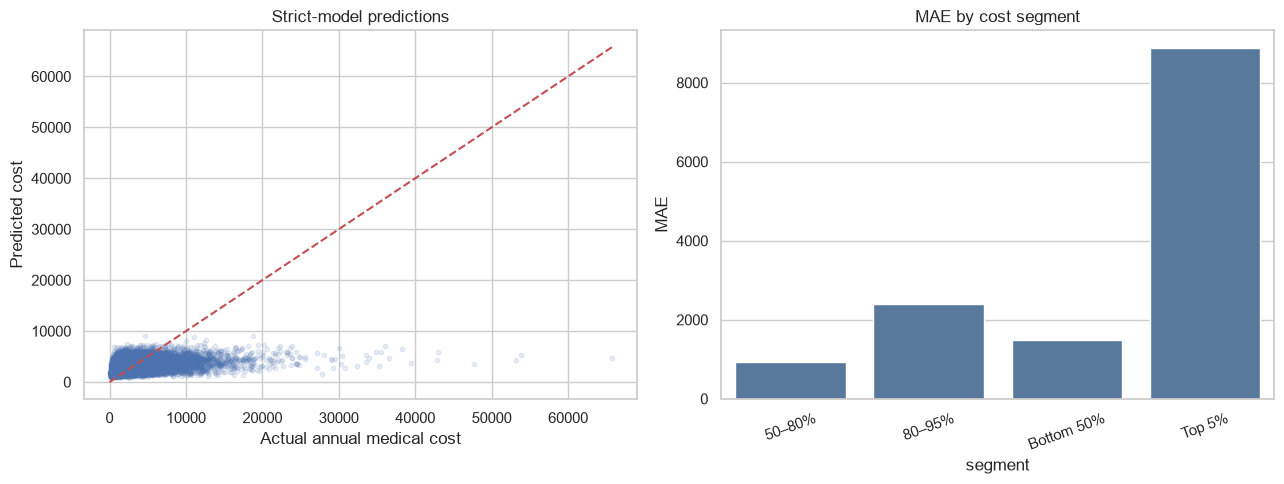

In [10]:
primary_model = final_models[("Strict", selected_regression_model)]
primary_prediction = primary_model.predict(X_test[strict_features])

train_cutoffs = y_train.quantile([0.50, 0.80, 0.95]).to_numpy()
segment_labels = ["Bottom 50%", "50–80%", "80–95%", "Top 5%"]
test_segments = pd.cut(
    y_test,
    bins=[-np.inf, *train_cutoffs, np.inf],
    labels=segment_labels,
    include_lowest=True,
)
error_frame = pd.DataFrame(
    {"actual": y_test.to_numpy(), "prediction": primary_prediction, "segment": test_segments.to_numpy()}
)
error_frame["absolute_error"] = (error_frame["actual"] - error_frame["prediction"]).abs()
segment_errors = (
    error_frame.groupby("segment", observed=True)
    .agg(rows=("actual", "size"), actual_mean=("actual", "mean"), MAE=("absolute_error", "mean"))
    .reset_index()
)
display(segment_errors.round({"actual_mean": 2, "MAE": 2}))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, primary_prediction, alpha=0.12, s=10)
limit = max(float(y_test.max()), float(primary_prediction.max()))
axes[0].plot([0, limit], [0, limit], "r--", linewidth=1.5)
axes[0].set(xlabel="Actual annual medical cost", ylabel="Predicted cost", title="Strict-model predictions")
sns.barplot(data=segment_errors, x="segment", y="MAE", ax=axes[1], color="#4C78A8")
axes[1].tick_params(axis="x", rotation=20)
axes[1].set_title("MAE by cost segment")
plt.tight_layout()
plt.show()


## 5. Model interpretation with permutation importance


,feature,importance_mean,importance_std
11,smoker,85.033595,10.012527
24,chronic_count,51.120088,2.631149
0,age,32.550519,1.686229
25,hypertension,11.839237,2.224390
10,bmi,7.879214,1.579977
33,arthritis,6.985402,0.612682
29,cardiovascular_disease,6.541183,1.201583
26,diabetes,6.122669,3.737385
34,mental_health,5.922585,2.785622
28,copd,4.372127,2.743708


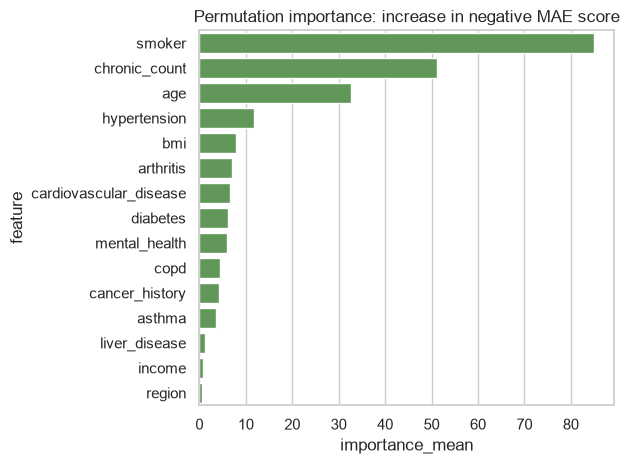

In [11]:
importance_sample = X_test[strict_features].sample(
    n=min(3000, len(X_test)), random_state=RANDOM_STATE
)
importance_target = y_test.loc[importance_sample.index]
importance = permutation_importance(
    primary_model,
    importance_sample,
    importance_target,
    scoring="neg_mean_absolute_error",
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
importance_table = (
    pd.DataFrame(
        {
            "feature": strict_features,
            "importance_mean": importance.importances_mean,
            "importance_std": importance.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .head(15)
)
display(importance_table)
sns.barplot(data=importance_table, y="feature", x="importance_mean", color="#59A14F")
plt.title("Permutation importance: increase in negative MAE score")
plt.tight_layout()
plt.show()


## 6. High-cost identification derived from the cost target

The original `is_high_risk` field is not used: its provenance is undocumented and the near-perfect scores suggest a derived rule that can be reconstructed from other columns. Instead, high cost is defined as cost above the **training-set 80th percentile**. The threshold is computed from training data only and then applied unchanged to validation and test data.

This remains a cross-sectional classification exercise, not a clinical diagnosis.


In [12]:
high_cost_cutoff = float(y_train.quantile(0.80))
y_train_high = (y_train >= high_cost_cutoff).astype(int)
y_val_high = (y_val >= high_cost_cutoff).astype(int)
y_trainval_high = (y_trainval >= high_cost_cutoff).astype(int)
y_test_high = (y_test >= high_cost_cutoff).astype(int)

print(f"Training-derived high-cost cutoff: {high_cost_cutoff:.2f}")
print(
    "Positive rates:",
    {"train": y_train_high.mean(), "validation": y_val_high.mean(), "test": y_test_high.mean()},
)


def classification_metrics(y_true, probability, threshold: float = 0.5) -> dict[str, float]:
    prediction = (probability >= threshold).astype(int)
    return {
        "ROC_AUC": roc_auc_score(y_true, probability),
        "PR_AUC": average_precision_score(y_true, probability),
        "Precision": precision_score(y_true, prediction, zero_division=0),
        "Recall": recall_score(y_true, prediction, zero_division=0),
        "F1": f1_score(y_true, prediction, zero_division=0),
        "Brier": brier_score_loss(y_true, probability),
    }


classifiers = {
    "Prior baseline": DummyClassifier(strategy="prior"),
    "Logistic Regression": LogisticRegression(
        max_iter=1500, random_state=RANDOM_STATE
    ),
    "Balanced Logistic Regression": LogisticRegression(
        max_iter=1500, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=16,
        min_samples_leaf=5,
        max_features=0.7,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}


Training-derived high-cost cutoff: 4292.25
Positive rates: {'train': np.float64(0.2), 'validation': np.float64(0.1925), 'test': np.float64(0.20045)}


In [13]:
validation_classification_rows = []
validation_classification_models = {}
for model_name, estimator in classifiers.items():
    pipeline = Pipeline(
        [("preprocess", make_preprocessor(X_train, strict_features)), ("model", clone(estimator))]
    )
    pipeline.fit(X_train[strict_features], y_train_high)
    probability = pipeline.predict_proba(X_val[strict_features])[:, 1]
    validation_classification_rows.append(
        {"Model": model_name, **classification_metrics(y_val_high, probability)}
    )
    validation_classification_models[model_name] = pipeline

validation_classification = (
    pd.DataFrame(validation_classification_rows).sort_values("PR_AUC", ascending=False)
)
display(validation_classification.round(4))
baseline_brier = float(
    validation_classification.loc[
        validation_classification["Model"] == "Prior baseline", "Brier"
    ].iloc[0]
)
eligible = validation_classification[
    (validation_classification["Model"] != "Prior baseline")
    & (validation_classification["Brier"] <= baseline_brier)
]
if eligible.empty:
    selected_classifier_name = validation_classification.sort_values("Brier").iloc[0]["Model"]
else:
    selected_classifier_name = eligible.sort_values("PR_AUC", ascending=False).iloc[0]["Model"]

selected_validation_classifier = validation_classification_models[selected_classifier_name]
selected_validation_probability = selected_validation_classifier.predict_proba(
    X_val[strict_features]
)[:, 1]
threshold_grid = np.linspace(0.05, 0.95, 181)
threshold_scores = [
    f1_score(y_val_high, selected_validation_probability >= threshold)
    for threshold in threshold_grid
]
selected_probability_threshold = float(threshold_grid[int(np.argmax(threshold_scores))])
print("Selected classifier:", selected_classifier_name)
print(f"Validation-selected probability threshold: {selected_probability_threshold:.3f}")


,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,Brier
1,Logistic Regression,0.7095,0.3669,0.5210,0.0932,0.1582,0.1416
2,Balanced Logistic Regression,0.7094,0.3660,0.3209,0.6244,0.4239,0.2151
3,Random Forest,0.6977,0.3494,0.3302,0.5387,0.4094,0.1914
0,Prior baseline,0.5000,0.1925,0.0000,0.0000,0.0000,0.1555


Selected classifier: Logistic Regression
Validation-selected probability threshold: 0.205


,ROC_AUC,PR_AUC,Precision,Recall,F1,Brier
Logistic Regression,0.7026,0.3819,0.3329,0.5907,0.4258,0.1458


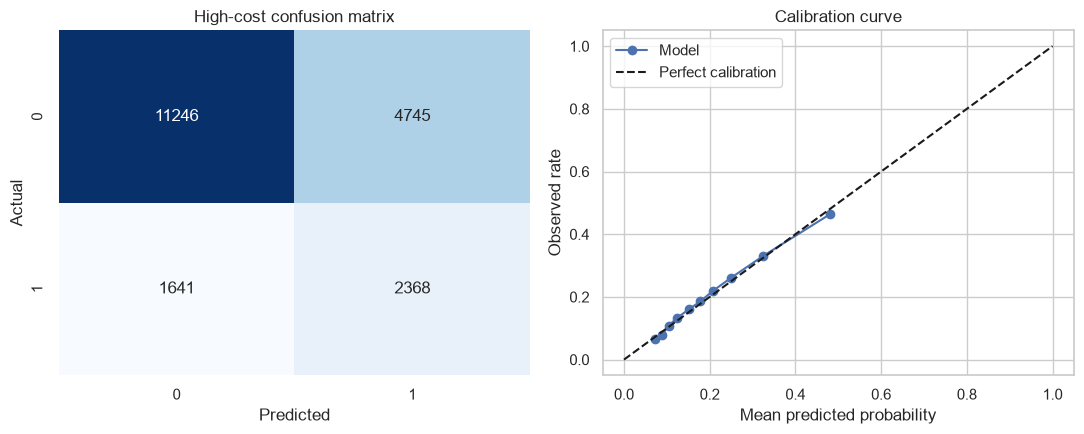

In [14]:
final_classifier = Pipeline(
    [
        ("preprocess", make_preprocessor(X_trainval, strict_features)),
        ("model", clone(classifiers[selected_classifier_name])),
    ]
)
final_classifier.fit(X_trainval[strict_features], y_trainval_high)
test_probability = final_classifier.predict_proba(X_test[strict_features])[:, 1]
test_classification = classification_metrics(
    y_test_high, test_probability, threshold=selected_probability_threshold
)
display(pd.DataFrame([test_classification], index=[selected_classifier_name]).round(4))

test_class_prediction = (test_probability >= selected_probability_threshold).astype(int)
matrix = confusion_matrix(y_test_high, test_class_prediction)
observed, predicted = calibration_curve(y_test_high, test_probability, n_bins=10, strategy="quantile")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set(xlabel="Predicted", ylabel="Actual", title="High-cost confusion matrix")
axes[1].plot(predicted, observed, marker="o", label="Model")
axes[1].plot([0, 1], [0, 1], "k--", label="Perfect calibration")
axes[1].set(xlabel="Mean predicted probability", ylabel="Observed rate", title="Calibration curve")
axes[1].legend()
plt.tight_layout()
plt.show()


In [15]:
strict_test_row = test_results[
    (test_results["Feature set"] == "Strict")
    & (test_results["Model"] == selected_regression_model)
].iloc[0]
extended_test_row = test_results[
    (test_results["Feature set"] == "Strict + ambiguous history")
    & (test_results["Model"] == selected_regression_model)
].iloc[0]
baseline_test_row = test_results[
    (test_results["Feature set"] == "Strict")
    & (test_results["Model"] == "Median baseline")
].iloc[0]
rmse_reduction = 100 * (baseline_test_row["RMSE"] - strict_test_row["RMSE"]) / baseline_test_row["RMSE"]
extended_rmse_change = 100 * (strict_test_row["RMSE"] - extended_test_row["RMSE"]) / strict_test_row["RMSE"]
top_segment_mae = float(
    segment_errors.loc[segment_errors["segment"] == "Top 5%", "MAE"].iloc[0]
)

display(Markdown(f'''
## 7. Results-based interpretation

- The validation-selected strict model was **{selected_regression_model}**. On the untouched test set it achieved **R² = {strict_test_row['R2']:.4f}**, **RMSE = {strict_test_row['RMSE']:.2f}**, and **MAE = {strict_test_row['MAE']:.2f}**.
- Relative to the median baseline, the strict model reduced test RMSE by **{rmse_reduction:.1f}%**. Its MAE advantage was much smaller, so the main gain came from reducing some large squared errors rather than uniformly improving every prediction.
- Adding ambiguous utilization-history variables changed RMSE by **{extended_rmse_change:.1f}%** and increased R² from **{strict_test_row['R2']:.4f}** to **{extended_test_row['R2']:.4f}**. This is a sensitivity result, not the primary prospective estimate, because timestamps are unavailable.
- Error remained highly concentrated in expensive cases: MAE for the training-defined top 5% cost segment was **{top_segment_mae:.2f}**.
- The high-cost classifier achieved **ROC-AUC = {test_classification['ROC_AUC']:.4f}**, **PR-AUC = {test_classification['PR_AUC']:.4f}**, **precision = {test_classification['Precision']:.4f}**, **recall = {test_classification['Recall']:.4f}**, and **Brier score = {test_classification['Brier']:.4f}** using a validation-selected threshold of **{selected_probability_threshold:.3f}**.

These results are deliberately lower than the earlier `R² = 0.945` and near-perfect classification scores because contemporaneous financial outcomes, claims aggregates, and undocumented derived risk fields were excluded from the primary feature set.
'''))



## 7. Results-based interpretation

- The validation-selected strict model was **Ridge**. On the untouched test set it achieved **R² = 0.1242**, **RMSE = 2935.69**, and **MAE = 1830.03**.
- Relative to the median baseline, the strict model reduced test RMSE by **10.4%**. Its MAE advantage was much smaller, so the main gain came from reducing some large squared errors rather than uniformly improving every prediction.
- Adding ambiguous utilization-history variables changed RMSE by **3.2%** and increased R² from **0.1242** to **0.1793**. This is a sensitivity result, not the primary prospective estimate, because timestamps are unavailable.
- Error remained highly concentrated in expensive cases: MAE for the training-defined top 5% cost segment was **8877.14**.
- The high-cost classifier achieved **ROC-AUC = 0.7026**, **PR-AUC = 0.3819**, **precision = 0.3329**, **recall = 0.5907**, and **Brier score = 0.1458** using a validation-selected threshold of **0.205**.

These results are deliberately lower than the earlier `R² = 0.945` and near-perfect classification scores because contemporaneous financial outcomes, claims aggregates, and undocumented derived risk fields were excluded from the primary feature set.


## 8. Limitations

Dataset provenance and its stated temporal relationship are documented on the Kaggle data card, but row-level feature timestamps are unavailable. The table is cross-sectional, random splitting does not test temporal or hospital-level generalization, and permutation importance is associational rather than causal. A single train/validation/test split does not quantify seed sensitivity; repeated splits or bootstrap confidence intervals remain future work.

### Claims this notebook does not support

- deployment readiness;
- causal effects of patient attributes;
- next-year forecasting without a temporal index;
- clinical decision support;
- superiority based only on a single random split.
